In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
!pip install -Uqq fastai fastbook
import fastbook
import fastai
from fastai import *
from fastbook import *
print(fastai.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.9/242.9 kB 3.5 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 16.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.4/153.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.1/124.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 246.9/246.9 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.6 MB/s eta 0:00:00:00:01
2.8.12


In [3]:
from fastai.vision.widgets import *

In [4]:
key = os.environ.get('SERP_API_KEY', '8c04c8cff7437e286a65550e7770d0ae95049c5322f2cfbe529790d8b4ea655d')

In [5]:
search_images_serpapi

<function fastai.vision.utils.search_images_serpapi(term, engine='bing_images', key=None, max_images=150)>

In [6]:
results = search_images_serpapi('grizzly bear', key=key)
ims = results
len(ims)

141

In [8]:
bear_types = 'grizzly','black','teddy'
path = Path('bears')

In [9]:

if not path.exists():
    path.mkdir()
    for o in bear_types:
        dest = (path/o)
        dest.mkdir(exist_ok=True)
        results = search_images_serpapi(f'{o} bear', key=key)
        download_images(dest, urls=results)

In [10]:
fns =  get_image_files(path)
fns

(#409) [Path('bears/teddy/f3af658a-c16f-4937-8d0c-120b2c39c448.jpg'), Path('bears/teddy/ef188b46-b06f-4d64-bd10-070d1c4c5998.jpeg'), Path('bears/teddy/2649b573-8dd7-4579-8850-7b6f01920fbc.jpg'), Path('bears/teddy/8a1fead6-d8c4-4dd8-8c83-c377c443f714.jpg'), Path('bears/teddy/9e64d1fd-9ca8-4d4e-9a1e-5de25c5593cc.jpg'), Path('bears/teddy/2eddc807-1053-43b2-876e-f7b0307fe9fd.jpg'), Path('bears/teddy/564d2807-1fce-4a90-92e8-962b48a262b5.jpg'), Path('bears/teddy/d3fa0608-f53c-4870-a576-8fccf2ce47e1.jpeg'), Path('bears/teddy/9d5cf834-7f9a-41ce-bc65-92fcab4c2373.jpg'), Path('bears/teddy/38521c7f-3ee2-4942-8bf1-e1ae343fd657.jpg'), Path('bears/teddy/a239708f-9090-40b3-aecd-d322e9a68e6a.jpg'), Path('bears/teddy/9da242c3-dbcb-47d0-a202-6259b738f135.jpg'), Path('bears/teddy/c4467ebf-97a3-423e-9886-25f39556e948.png'), Path('bears/teddy/1968b751-eee4-4fef-a356-20a69df49223.jpg'), Path('bears/teddy/b2b23d8c-425d-4ba0-8ec1-c50109685a52.jpg'), Path('bears/teddy/b30dac1f-c6ac-49d5-9884-5cff7561de61.jpg')

In [12]:
failed = verify_images(fns)
failed

[Path('bears/grizzly/2b80db6d-303d-48c1-ad7d-a58dd15b17a9.jpg'), Path('bears/black/4caabc8a-c89d-4f3b-b052-1ce598f23fc1.jpg')]

In [14]:
failed.map(Path.unlink);

In [15]:
??verify_images

Signature: verify_images(fns)
Source:   
def verify_images(fns):
    "Find images in `fns` that can't be opened"
    return L(fns[i] for i,o in enumerate(parallel(verify_image, fns)) if not o)
File:      /usr/local/lib/python3.12/dist-packages/fastai/vision/utils.py
Type:      function


# From Data to DataLoaders

In [18]:
bears = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items=get_image_files,
    splitter = RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128)
)

In [19]:
dls = bears.dataloaders(path)

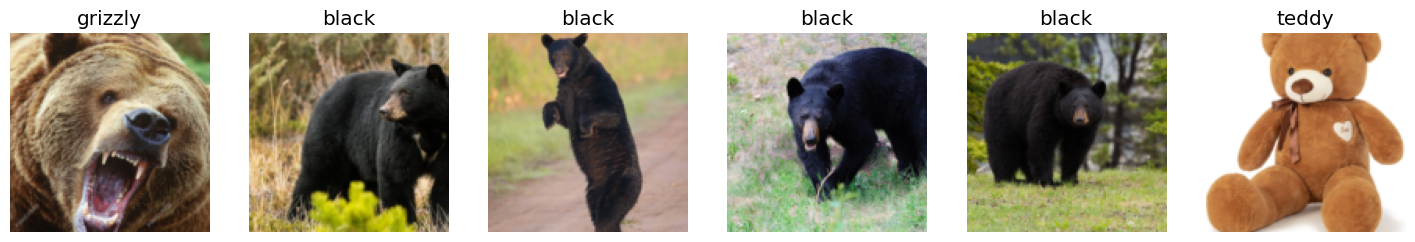

In [20]:
dls.valid.show_batch(max_n=6, nrows=1)

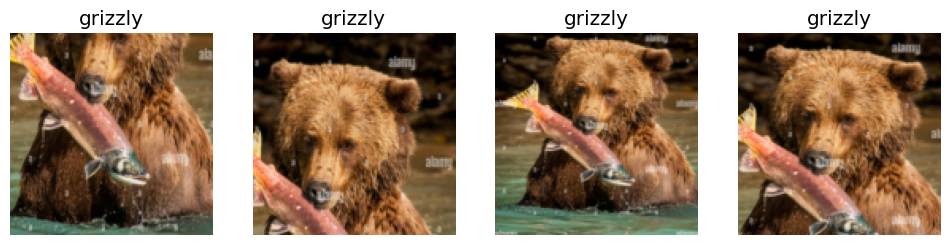

In [21]:
bears = bears.new(item_tfms=RandomResizedCrop(128, min_scale=0.3))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=4, nrows=1, unique=True)

# Data Augmentation
Data augmentation refers to creating random variations of our input data, such that they appear different, but do not actually change the meaning of the data. Examples of common data augmentation techniques for images are rotation, flipping, perspective warping, brightness changes and contrast changes. For natural photo images such as the ones we are using here, a standard set of augmentations that we have found work pretty well are provided with the aug_transforms function. Because our images are now all the same size, we can apply these augmentations to an entire batch of them using the GPU, which will save a lot of time. To tell fastai we want to use these transforms on a batch, we use the batch_tfms parameter (note that we're not using RandomResizedCrop in this example, so you can see the differences more clearly; we're also using double the amount of augmentation compared to the default, for the same reason):

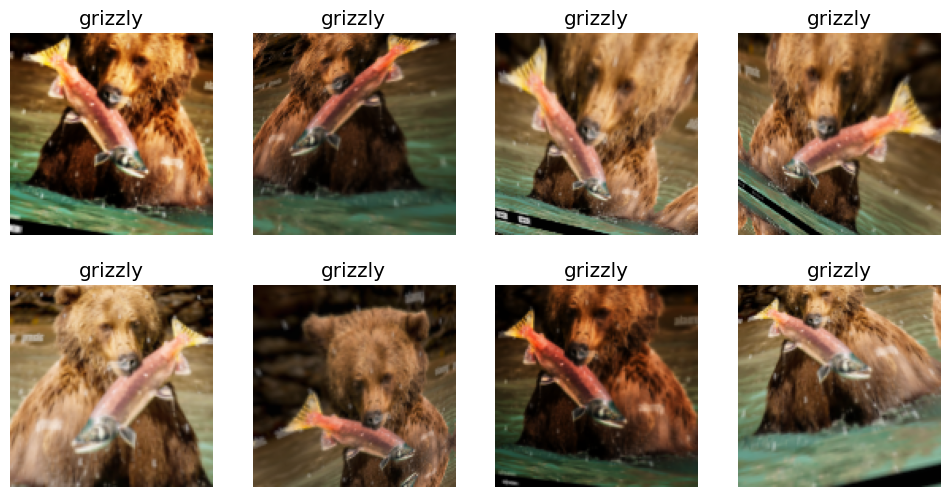

In [23]:
bears = bears.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
dls = bears.dataloaders(path)
dls.train.show_batch(max_n=8, nrows=2, unique=True)

# Training Your Model, and Using It to Clean Your Data
Time to use the same lines of code as in <<chapter_intro>> to train our bear classifier.

We don't have a lot of data for our problem (150 pictures of each sort of bear at most), so to train our model, we'll use RandomResizedCrop with an image size of 224 px, which is fairly standard for image classification, and default aug_transforms:

In [25]:
bears = bears.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms()
    )
dls = bears.dataloaders(path)

In [26]:
learn = vision_learner(dls,resnet18, metrics=error_rate)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 169MB/s]


In [28]:
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,1.396849,0.092524,0.061728,01:15


epoch,train_loss,valid_loss,error_rate,time
0,0.132368,0.045350,0.024691,01:42
1,0.108076,0.011896,0.000000,01:41
2,0.074751,0.030250,0.024691,01:40
3,0.068304,0.025565,0.024691,01:41


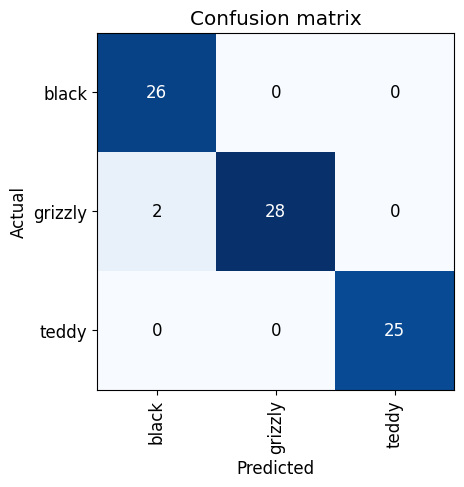

In [30]:
interp=ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

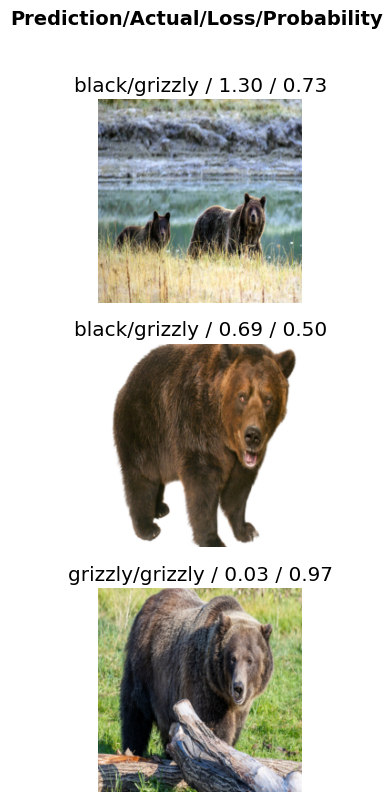

In [36]:
interp.plot_top_losses(3,nrows=3)

In [37]:
cleaner = ImageClassifierCleaner(learn)
cleaner

In [38]:
for idx in cleaner.delete(): cleaner.fns[idx].unlink()
    # for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), path/cat)

# Using the Model for Inference

In [40]:
learn.export()

#Checking if file exists
path = Path()
path.ls(file_exts='.pkl')

[Path('export.pkl')]

In [42]:
learn_inf = load_learner(path/'export.pkl')

In [45]:
learn_inf.predict('/kaggle/input/datasets/richardwg2/images/medium-3406535235.jpg')

('grizzly', tensor(1), tensor([2.6699e-05, 9.9997e-01, 1.2900e-07]))

In [47]:
learn_inf.dls.vocab

['black', 'grizzly', 'teddy']

# Creating a Notebook App from the Model

In [48]:
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value=(), description='Upload')

In [51]:
#img = PILImage.create(btn_upload.data[-1])
img = PILImage.create(btn_upload.value[0]['content'].tobytes())

In [53]:
out_pl = widgets.Output()
out_pl.clear_output()
with out_pl:display(img.to_thumb(128,128))
out_pl

Output()

In [54]:
pred, pred_idx,probs = learn_inf.predict(img)

In [55]:
lbl_pred = widgets.Label()
lbl_pred.value = f'Prediction:{pred}; Probability: {probs[pred_idx]:.04f}'
lbl_pred

Label(value='Prediction:teddy; Probability: 0.9999')

In [56]:
btn_run = widgets.Button(description ='Classify')
btn_run

Button(description='Classify', style=ButtonStyle())

In [62]:
def on_click_classify(change):
    img = PILImage.create(btn_upload.value[0]['content'].tobytes())
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs = learn_inf.predict(img)
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'
    lbl_pred


btn_run.on_click(on_click_classify)

We can now put them all in a vertical box (VBox) to complete our GUI:

In [63]:
btn_upload = widgets.FileUpload()

In [64]:
VBox([widgets.Label('Select your bear!'),
    btn_upload,btn_run, out_pl, lbl_pred])

# Turning Your Notebook into a Real App

In [65]:
!pip install voila


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 38.7 MB/s eta 0:00:0000:0100:01
usage: jupyter [-h] [--version] [--config-dir] [--data-dir] [--runtime-dir]
               [--paths] [--json] [--debug]
               [subcommand]

Jupyter: Interactive Computing

positional arguments:
  subcommand     the subcommand to launch

options:
  -h, --help     show this help message and exit
  --version      show the versions of core jupyter packages and exit
  --config-dir   show Jupyter config dir
  --data-dir     show Jupyter data dir
  --runtime-dir  show Jupyter runtime dir
  --paths        show all Jupyter paths. Add --json for machine-readable
                 format.
  --json         output paths as machine-readable json
  --debug        output debug information about paths

Available subcommands: bundlerextension console dejavu events execute fileid
kernel kernelgateway kernelspec lab labextension labhub migrate nbclassic
nbconvert nbextension notebook qtconsole run server servere

In [67]:
!jupyter serverextension enable --sys-prefix voila 

Enabling: voila
- Writing config: /usr/etc/jupyter
    - Validating...
/usr/local/lib/python3.12/dist-packages/mistune.py:435: SyntaxWarning: invalid escape sequence '\|'
  cells[i][c] = re.sub('\\\\\|', '|', cell)
/usr/local/lib/python3.12/dist-packages/nbconvert/filters/filter_links.py:36: SyntaxWarning: invalid escape sequence '\_'
  text = re.sub(r'_', '\_', text) # Escape underscores in display text
      voila 0.5.13 OK
